# Customer Segmentation (K-Means)

This project uses K-Means clustering to group customers based on their purchasing behavior. After preprocessing, encoding, scaling, and applying PCA, the optimal number of clusters was found to be **4**.

---

## Cluster Summary

### Cluster 0 – Footwear Customers
Customers who mainly buy sandals, shoes, and sneakers, mostly during spring and summer.

### Cluster 1 – Regular Shoppers
Customers who frequently purchase clothing and accessories across all seasons.

### Cluster 2 – Casual Buyers
Customers with balanced shopping behavior, buying items like pants, sweaters, and hats.

### Cluster 3 – Seasonal Outerwear Buyers
Customers focused on jackets and coats, mainly during fall and winter.

---

## Insight
Customer groups are formed based on purchasing behavior rather than age or spending.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("shopping_trends_updated.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [16]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [17]:
df_encoded = df.copy()
df = df.drop('Customer ID', axis=1)
df_encoded = df_encoded.drop('Customer ID', axis=1)

cat_cols = ['Gender', 'Item Purchased', 'Category', 'Location', 
            'Size', 'Color', 'Season', 'Subscription Status',
            'Shipping Type', 'Discount Applied', 'Promo Code Used',
            'Payment Method', 'Frequency of Purchases']

df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("Columns:", df_encoded.shape[1])

Shape after encoding: (3900, 130)
Columns: 130


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.10)
X_pca = pca.fit_transform(X_scaled)

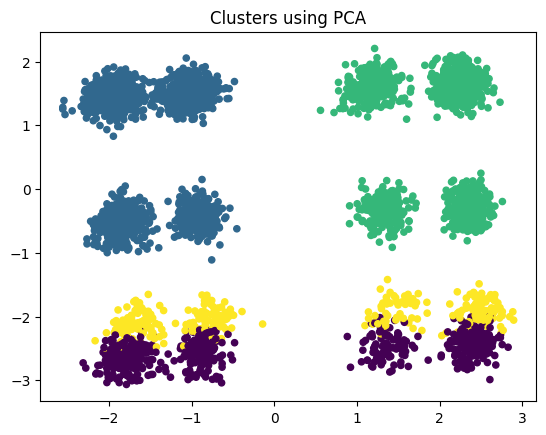

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
y = kmeans.fit_predict(X_pca)
df["cluster"] = y

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20)
plt.title("Clusters using PCA")
plt.show()

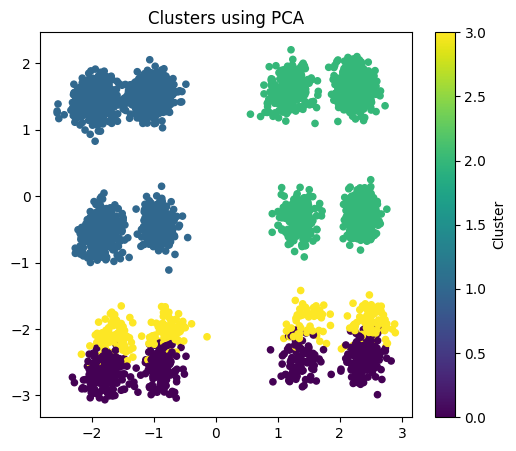

In [21]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap="viridis")
plt.colorbar(label="Cluster")
plt.title("Clusters using PCA")
plt.show()

In [22]:
df.groupby("cluster").mean(numeric_only=True)

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
cluster,,,,
0,44.442404,60.255426,3.790651,25.232053
1,43.910159,60.496183,3.750029,25.234880
2,44.042386,59.214286,3.731476,25.664050
3,44.311728,57.172840,3.746914,24.956790


In [23]:
cat_cols = ['Item Purchased','Category','Color','Season','Location']

for col in cat_cols:
    print("\n====", col, "====")
    print(df.groupby("cluster")[col].value_counts().groupby(level=0).head(3))


==== Item Purchased ====
cluster  Item Purchased
0        Sandals           160
         Shoes             150
         Sneakers          145
1        Blouse            113
         Socks             107
         Shirt              98
2        Pants              81
         Sweater            79
         Hat                77
3        Jacket            163
         Coat              161
Name: count, dtype: int64

==== Category ====
cluster  Category   
0        Footwear        599
1        Clothing       1006
         Accessories     697
2        Clothing        731
         Accessories     543
3        Outerwear       324
Name: count, dtype: int64

==== Color ====
cluster  Color   
0        Olive       31
         Violet      30
         Yellow      30
1        Green       79
         Black       77
         Magenta     77
2        Charcoal    64
         Teal        61
         Yellow      60
3        Blue        19
         Olive       19
         Cyan        16
Name: count, dtype:

In [24]:
for col in cat_cols:
    print("\n====", col, "====")
    print(
        df.groupby("cluster")[col]
        .value_counts(normalize=True)
        .groupby(level=0)
        .head(3)
    )


==== Item Purchased ====
cluster  Item Purchased
0        Sandals           0.267112
         Shoes             0.250417
         Sneakers          0.242070
1        Blouse            0.066353
         Socks             0.062830
         Shirt             0.057546
2        Pants             0.063579
         Sweater           0.062009
         Hat               0.060440
3        Jacket            0.503086
         Coat              0.496914
Name: proportion, dtype: float64

==== Category ====
cluster  Category   
0        Footwear       1.000000
1        Clothing       0.590722
         Accessories    0.409278
2        Clothing       0.573783
         Accessories    0.426217
3        Outerwear      1.000000
Name: proportion, dtype: float64

==== Color ====
cluster  Color   
0        Olive       0.051753
         Violet      0.050083
         Yellow      0.050083
1        Green       0.046389
         Black       0.045214
         Magenta     0.045214
2        Charcoal    0.050235
    